# Flight Departure Delay Prediction — LightGBM


## Step 1 - Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
import optuna
import warnings
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score,
    precision_recall_curve, RocCurveDisplay, average_precision_score
)
import joblib
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)
from imblearn.over_sampling import SMOTE

## Step 2 - Load Data and Analysis

### 2.1 View Dataset

In [2]:
train = pd.read_csv("flight_dataset_v2.csv")

print(f"Training Data")
print(f"Shape: {train.shape}")
print(train.head())
print(train.info())
print(train.describe())

Training Data
Shape: (9754, 51)
  id             airline origin_code destination_code    route aircraft_type  \
0  1  SriLankan Airlines         CMB              BOM  CMB_BOM          A21N   
1  2  SriLankan Airlines         CMB              BOM  CMB_BOM          A332   
2  3  SriLankan Airlines         CMB              BOM  CMB_BOM          A21N   
3  4  SriLankan Airlines         CMB              BOM  CMB_BOM          A20N   
4  5  SriLankan Airlines         CMB              BOM  CMB_BOM          A320   

  scheduled_departure_time actual_departure_time scheduled_arrival_time  \
0          12/1/2025 23:40        12/2/2025 1:44         12/2/2025 2:10   
1         11/30/2025 23:40        12/1/2025 2:04         12/1/2025 2:10   
2          11/30/2025 8:28       11/30/2025 8:28       11/30/2025 10:28   
3         11/29/2025 23:40                     0        11/30/2025 2:10   
4         11/28/2025 23:40                     0        11/29/2025 2:10   

  actual_arrival_time  ...  arr_weat

### 2.2 Check Missing Values

In [3]:
train.isna().sum()

id                                   0
airline                              0
origin_code                          0
destination_code                     0
route                                0
aircraft_type                        0
scheduled_departure_time             0
actual_departure_time                0
scheduled_arrival_time               0
actual_arrival_time                  0
departure_delay_min                  0
arrival_delay_min                    0
is_diverted                          0
is_cancelled                         0
is_sri_lankan_public_holiday         0
is_poya_day                          0
is_festival_period                   0
is_post_holiday                      0
is_long_weekend                      0
dep_date_only                        0
scheduled_departure_hour             0
scheduled_arrival_hour               0
scheduled_departure_day_of_week      0
scheduled_arrival_day_of_week        0
scheduled_is_weekend                 0
scheduled_month          

#### Correlation Matrix

## Step 3 — Preprocessing & Feature Engineering

### 3.1 Drop Columns

In [4]:
# Remove cancelled & diverted (no real delay value)
print(f"Cancelled : {train['is_cancelled'].sum()} rows removed")
print(f"Diverted  : {train['is_diverted'].sum()} rows removed")

df = train[
    (train['is_cancelled'] == 0) &
    (train['is_diverted']  == 0)
].copy().reset_index(drop=True)

print(f"\nClean shape: {df.shape}")

# ── Verify target ────────────────────────────────────────────────────────────
print(f"\ndeparture_delay_min range: [{df['departure_delay_min'].min()}, {df['departure_delay_min'].max()}]")
print(f"Negative delays: {(df['departure_delay_min'] < 0).sum()}  (early departures — treat as 0)")
df['departure_delay_min'] = df['departure_delay_min'].clip(lower=0)

Cancelled : 52 rows removed
Diverted  : 10 rows removed

Clean shape: (9692, 51)

departure_delay_min range: [-22, 1012]
Negative delays: 1269  (early departures — treat as 0)


In [5]:
drop_cols = [
    'id', 'dep_date_only',
    'actual_departure_time', 'actual_arrival_time',
    'departure_delay_min', 'arrival_delay_min',
    'binary_delay_arr', 
    'delay_class_dep', 
    'delay_class_arr',
    'scheduled_departure_time', 'scheduled_arrival_time',
    'origin_code',
    'is_diverted', 'is_cancelled',
    # 'route_avg_delay', 'route_delay_rate', 'airline_avg_delay', 'airline_delay_rate', 'aircraft_avg_delay'
]

df = df.drop(columns=[c for c in drop_cols if c in df.columns])

print(f"Shape after dropping: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

Shape after dropping: (9692, 37)
Remaining columns: ['airline', 'destination_code', 'route', 'aircraft_type', 'is_sri_lankan_public_holiday', 'is_poya_day', 'is_festival_period', 'is_post_holiday', 'is_long_weekend', 'scheduled_departure_hour', 'scheduled_arrival_hour', 'scheduled_departure_day_of_week', 'scheduled_arrival_day_of_week', 'scheduled_is_weekend', 'scheduled_month', 'scheduled_is_peak_hour', 'scheduled_early_morning_departure', 'scheduled_late_night_departure', 'scheduled_flight_duration_min', 'is_short_haul', 'dep_is_monsoon_season', 'dep_wind_speed_10m', 'dep_cloud_cover', 'dep_visibility', 'dep_precipitation', 'dep_weather_code', 'arr_wind_speed_10m', 'arr_cloud_cover', 'arr_visibility', 'arr_precipitation', 'arr_weather_code', 'route_avg_delay', 'route_delay_rate', 'airline_avg_delay', 'airline_delay_rate', 'aircraft_avg_delay', 'binary_delay_dep']


### 3.2 Feature Engineering

In [6]:
def feature_engineering(df):

    df = df.drop(columns=[c for c in drop_cols if c in df.columns])

    # Cyclical Hour
    for col, prefix in [
        ('scheduled_departure_hour','dep'),
        ('scheduled_arrival_hour','arr')
    ]:
        if col in df.columns:
            df[f'{prefix}_hour_sin'] = np.sin(2*np.pi*df[col]/24)
            df[f'{prefix}_hour_cos'] = np.cos(2*np.pi*df[col]/24)

    # Cyclical Month
    if 'scheduled_month' in df.columns:
        df['month_sin'] = np.sin(2*np.pi*df['scheduled_month']/12)
        df['month_cos'] = np.cos(2*np.pi*df['scheduled_month']/12)

    # Day of week cyclical
    day_map = {
        'Monday':1,'Tuesday':2,'Wednesday':3,
        'Thursday':4,'Friday':5,
        'Saturday':6,'Sunday':7
    }

    for col in [
        'scheduled_departure_day_of_week',
        'scheduled_arrival_day_of_week'
    ]:
        if col in df.columns:
            if df[col].dtype == object:
                df[col] = df[col].map(day_map)
            df[col] = pd.to_numeric(df[col], errors='coerce')
            df[f'{col}_sin'] = np.sin(2*np.pi*df[col]/7)
            df[f'{col}_cos'] = np.cos(2*np.pi*df[col]/7)

    # Weather features
    if 'dep_precipitation' in df.columns and 'arr_precipitation' in df.columns:
        df['total_precipitation'] = df['dep_precipitation'] + df['arr_precipitation']
        df['any_precipitation'] = (
            (df['dep_precipitation'] > 0) |
            (df['arr_precipitation'] > 0)
        ).astype(int)

    if 'dep_visibility' in df.columns:
        df['dep_weather_risk'] = (
            df['dep_precipitation'] +
            df['dep_cloud_cover']/100 -
            df['dep_visibility']/50000
        )

    if 'arr_visibility' in df.columns:
        df['arr_weather_risk'] = (
            df['arr_precipitation'] +
            df['arr_cloud_cover']/100 -
            df['arr_visibility']/50000
        )

    if 'scheduled_late_night_departure' in df.columns and 'dep_is_monsoon_season' in df.columns:
        df['night_monsoon'] = (
            df['scheduled_late_night_departure'] *
            df['dep_is_monsoon_season']
        )

    return df

## Step 4 - Define Target & Features

In [7]:
TARGET = "binary_delay_dep"
X = df.drop(columns=['binary_delay_dep', 'scheduled_departure_day_of_week',
    'scheduled_arrival_day_of_week'])
y = df[TARGET]


categorical_features = [
    'airline',
    'aircraft_type',
    'destination_code',
    'route',
]

for col in categorical_features:
    if col in X.columns:
        X[col] = X[col].astype('category')



# Drop any remaining datetime or object columns
bad_cols = X.select_dtypes(include=['datetime64','object']).columns.tolist()
if bad_cols:
    print(f" Dropping non-numeric columns: {bad_cols}")
    X = X.drop(columns=bad_cols)
    categorical_features = [c for c in categorical_features if c not in bad_cols]

print(f"Feature matrix: {X.shape}")
print(f"Target distribution:\n{y.value_counts()}")
print(f"\nClass balance: {y.value_counts()[0]/y.value_counts()[1]:.2f}:1")


Feature matrix: (9692, 34)
Target distribution:
binary_delay_dep
0    6457
1    3235
Name: count, dtype: int64

Class balance: 2.00:1


## Step 5 - Train / Validation Split


In [8]:
X_train, X_valid, y_train, y_valid = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=42
)

In [9]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos
print("Class weight:", scale_pos_weight)

X_train_enc = X_train.copy()
X_valid_enc = X_valid.copy()

le_dict = {}
for col in categorical_features:
    if col in X_train_enc.columns:
        le = LabelEncoder()
        X_train_enc[col] = le.fit_transform(X_train_enc[col].astype(str))
        X_valid_enc[col] = le.transform(X_valid_enc[col].astype(str))
        le_dict[col] = le

sm = SMOTE(random_state=42)
X_train_res, y_train_res = sm.fit_resample(X_train_enc, y_train)

print(f"Before SMOTE : {dict(y_train.value_counts().sort_index())}")
print(f"After  SMOTE : {dict(pd.Series(y_train_res).value_counts().sort_index())}")

# Re-convert to category for LightGBM after SMOTE
X_train_res = pd.DataFrame(X_train_res, columns=X_train_enc.columns)
X_valid_enc = pd.DataFrame(X_valid_enc, columns=X_valid_enc.columns)
for col in categorical_features:
    if col in X_train_res.columns:
        X_train_res[col] = X_train_res[col].astype('category')
        X_valid_enc[col] = X_valid_enc[col].astype('category')

Class weight: 1.9957496136012365
Before SMOTE : {0: np.int64(5165), 1: np.int64(2588)}
After  SMOTE : {0: np.int64(5165), 1: np.int64(5165)}


## Step 6 - Hyperparameter Tuning with Optuna

In [10]:
RANDOM_STATE  = 42
TEST_SIZE     = 0.20
OPTUNA_TRIALS = 12      # increase to 150 for even better results
CV_FOLDS      = 5
EARLY_STOP    = 100

def objective(trial):
    params = {
        'objective':        'binary',
        'metric':           'auc',
        'boosting_type':    'gbdt',
        'verbosity':        -1,
        'seed':             42,
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 20, 200),
        'max_depth':        trial.suggest_int('max_depth', 3, 15),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 100),
        'feature_fraction': trial.suggest_float('feature_fraction', 0.5, 1.0),
        'bagging_fraction': trial.suggest_float('bagging_fraction', 0.5, 1.0),
        'bagging_freq':     trial.suggest_int('bagging_freq', 1, 10),
        'lambda_l1':        trial.suggest_float('lambda_l1', 1e-4, 10.0, log=True),
        'lambda_l2':        trial.suggest_float('lambda_l2', 1e-4, 10.0, log=True),
        'min_split_gain':   trial.suggest_float('min_split_gain', 0.0, 0.3),
    }

    # Cross-validate on SMOTE-resampled training data only
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    auc_scores = []

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X_train_res, y_train_res)):
        X_tr  = X_train_res.iloc[tr_idx]
        X_val = X_train_res.iloc[val_idx]
        y_tr  = y_train_res.iloc[tr_idx] if hasattr(y_train_res, 'iloc') else y_train_res[tr_idx]
        y_val = y_train_res.iloc[val_idx] if hasattr(y_train_res, 'iloc') else y_train_res[val_idx]

        dtrain = lgb.Dataset(X_tr,  label=y_tr,  categorical_feature=categorical_features)
        dval   = lgb.Dataset(X_val, label=y_val, reference=dtrain,
                             categorical_feature=categorical_features)

        model = lgb.train(
            params, dtrain,
            num_boost_round=500,
            valid_sets=[dval],
            callbacks=[lgb.early_stopping(50, verbose=False),
                       lgb.log_evaluation(0)]
        )
        preds = model.predict(X_val, num_iteration=model.best_iteration)
        auc_scores.append(roc_auc_score(y_val, preds))

    return np.mean(auc_scores)

print(f"Running Optuna — 15 trials...")
study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=15, show_progress_bar=True)

print(f"\nBest CV ROC AUC : {study.best_value:.4f}")
print("Best parameters :")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")


Running Optuna — 15 trials...


  0%|          | 0/15 [00:00<?, ?it/s]


Best CV ROC AUC : 0.8677
Best parameters :
  learning_rate: 0.021773117775224102
  num_leaves: 103
  max_depth: 10
  min_child_samples: 28
  feature_fraction: 0.7234634250867139
  bagging_fraction: 0.7823360325349361
  bagging_freq: 5
  lambda_l1: 0.006158897414181275
  lambda_l2: 0.0006686863335311138
  min_split_gain: 0.23929222175785678


## Step7 - Train Final Model

In [11]:
best_params = study.best_params.copy()
best_params.update({
    'objective':     'binary',
    'metric':        'auc',
    'boosting_type': 'gbdt',
    'verbosity':     -1,
    'seed':          RANDOM_STATE,
    'device': 'gpu'
})

dtrain_final = lgb.Dataset(
    X_train_res, label=y_train_res,
    categorical_feature=categorical_features
)
dvalid_final = lgb.Dataset(
    X_valid_enc, label=y_valid,
    reference=dtrain_final,
    categorical_feature=categorical_features
)

# Track best_iteration so we use the right number of trees
callback_records = {}

final_model = lgb.train(
    best_params,
    dtrain_final,
    num_boost_round=2000,         # large ceiling — early stopping controls actual count
    valid_sets=[dvalid_final],
    callbacks=[
        lgb.early_stopping(EARLY_STOP, verbose=True),
        lgb.log_evaluation(100)
    ]
)

best_iter = final_model.best_iteration
print(f"\nBest iteration   : {best_iter}")
print(f"Best valid AUC   : {final_model.best_score['valid_0']['auc']:.4f}")


Training until validation scores don't improve for 100 rounds
[100]	valid_0's auc: 0.744082
[200]	valid_0's auc: 0.746254
Early stopping, best iteration is:
[156]	valid_0's auc: 0.746498

Best iteration   : 156
Best valid AUC   : 0.7465


## Step 8 - Evaluation on Unseen Validation Set

Default threshold (0.50) → F1: 0.5375
Tuned  threshold (0.3144) → F1: 0.6024


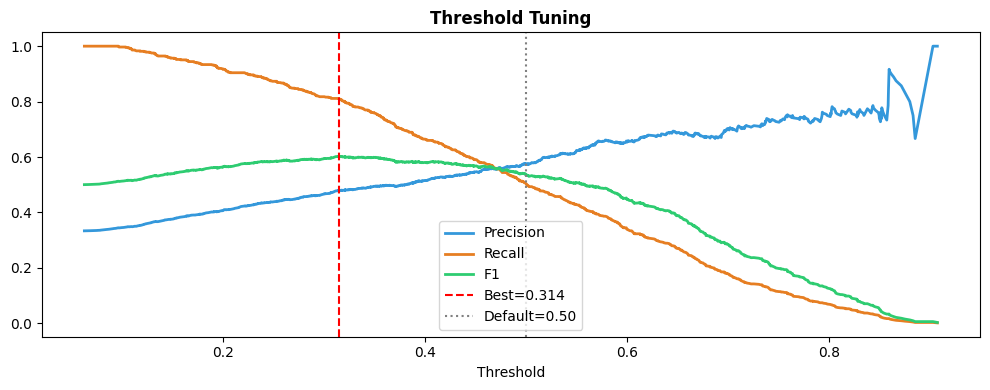

In [12]:
# Predict on truly unseen X_valid
val_probs = final_model.predict(X_valid_enc, num_iteration=best_iter)

# Find optimal threshold via F1 maximisation
precisions, recalls, thresholds = precision_recall_curve(y_valid, val_probs)
f1s = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-8)
best_idx   = np.argmax(f1s)
best_thresh = thresholds[best_idx]

print(f"Default threshold (0.50) → F1: {f1_score(y_valid, (val_probs>=0.50).astype(int)):.4f}")
print(f"Tuned  threshold ({best_thresh:.4f}) → F1: {f1s[best_idx]:.4f}")

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(thresholds, precisions[:-1], label='Precision', color='#3498db', lw=2)
ax.plot(thresholds, recalls[:-1],    label='Recall',    color='#e67e22', lw=2)
ax.plot(thresholds, f1s,             label='F1',        color='#2ecc71', lw=2)
ax.axvline(best_thresh, color='red',  linestyle='--', lw=1.5, label=f'Best={best_thresh:.3f}')
ax.axvline(0.50,        color='gray', linestyle=':',  lw=1.5, label='Default=0.50')
ax.set_xlabel('Threshold'); ax.set_title('Threshold Tuning', fontweight='bold')
ax.legend(); plt.tight_layout(); plt.show()

val_preds_default = (val_probs >= 0.5).astype(int)
val_preds_tuned   = (val_probs >= best_thresh).astype(int)

In [13]:
def print_metrics(y_true, y_pred, y_prob, label):
    print(f"\n{'='*55}")
    print(f"  {label}")
    print(f"{'='*55}")
    print(f"  Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"  ROC AUC   : {roc_auc_score(y_true, y_prob):.4f}")
    print(f"  F1 (macro): {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"  F1 (wtd)  : {f1_score(y_true, y_pred, average='weighted'):.4f}")
    print(f"  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"  Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['On-Time','Delayed']))

print_metrics(y_valid, val_preds_default, val_probs, "Default Threshold (0.50)")
print_metrics(y_valid, val_preds_tuned, val_probs, "Default Threshold (0.50)")



  Default Threshold (0.50)
  Accuracy  : 0.7107
  ROC AUC   : 0.7465
  F1 (macro): 0.6635
  F1 (wtd)  : 0.7054
  Precision : 0.5760
  Recall    : 0.5039

Classification Report:
              precision    recall  f1-score   support

     On-Time       0.77      0.81      0.79      1292
     Delayed       0.58      0.50      0.54       647

    accuracy                           0.71      1939
   macro avg       0.67      0.66      0.66      1939
weighted avg       0.70      0.71      0.71      1939


  Default Threshold (0.50)
  Accuracy  : 0.6426
  ROC AUC   : 0.7465
  F1 (macro): 0.6389
  F1 (wtd)  : 0.6511
  Precision : 0.4790
  Recall    : 0.8114

Classification Report:
              precision    recall  f1-score   support

     On-Time       0.86      0.56      0.68      1292
     Delayed       0.48      0.81      0.60       647

    accuracy                           0.64      1939
   macro avg       0.67      0.68      0.64      1939
weighted avg       0.73      0.64      0.65  

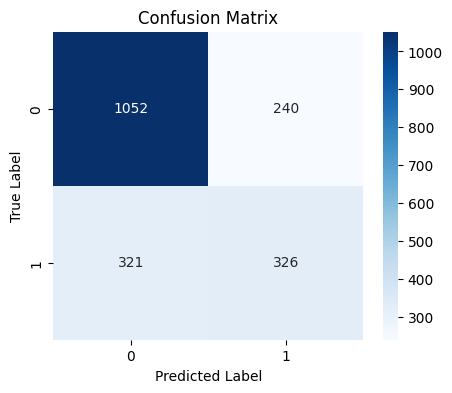

In [14]:
cm = confusion_matrix(y_valid, val_preds_default)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

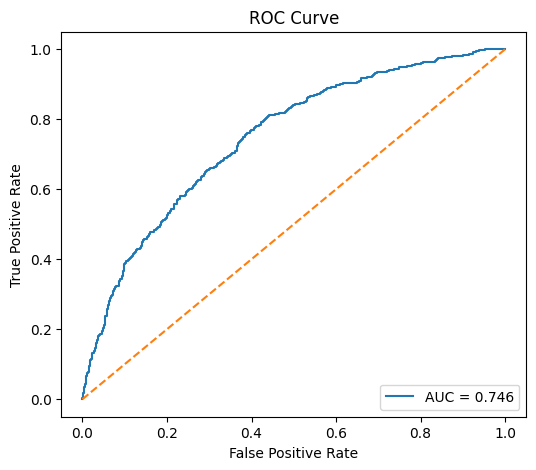

In [15]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve,auc, precision_score, recall_score
)

fpr, tpr, _ = roc_curve(y_valid, val_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()

## 12. Feature Importance

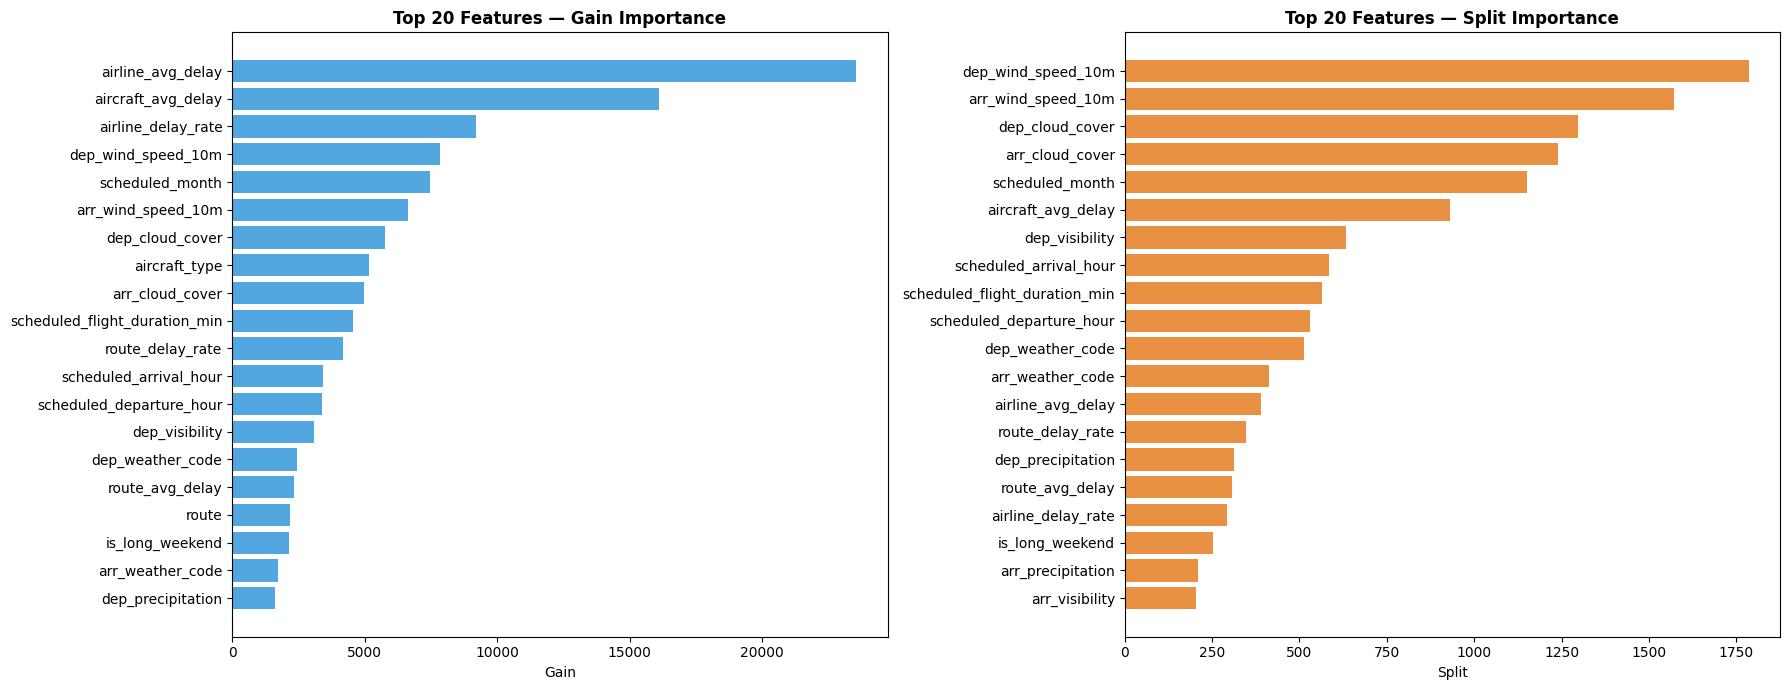

Top 15 features (Gain importance):
airline_avg_delay                23561.466215
aircraft_avg_delay               16111.595640
airline_delay_rate                9199.397463
dep_wind_speed_10m                7841.538632
scheduled_month                   7454.064557
arr_wind_speed_10m                6618.105115
dep_cloud_cover                   5766.806558
aircraft_type                     5156.398185
arr_cloud_cover                   4976.395287
scheduled_flight_duration_min     4575.051039
route_delay_rate                  4187.783110
scheduled_arrival_hour            3430.180986
scheduled_departure_hour          3383.858523
dep_visibility                    3080.196119
dep_weather_code                  2441.668819


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, importance_type in zip(axes, ['gain', 'split']):
    imp = pd.Series(
        final_model.feature_importance(importance_type=importance_type),
        index=X_train_res.columns
    ).sort_values(ascending=False).head(20)

    bars = ax.barh(imp.index[::-1], imp.values[::-1],
                   color='#3498db' if importance_type=='gain' else '#e67e22',
                   alpha=0.85)
    ax.set_title(f'Top 20 Features — {importance_type.capitalize()} Importance',
                 fontweight='bold')
    ax.set_xlabel(importance_type.capitalize())

plt.tight_layout(); plt.show()

# Print top 15
print("Top 15 features (Gain importance):")
gain_imp = pd.Series(
    final_model.feature_importance(importance_type='gain'),
    index=X_train_res.columns
).sort_values(ascending=False)
print(gain_imp.head(15).to_string())


## 13. Optuna Study Analysis

Optuna plot note: plot_optimization_history() got an unexpected keyword argument 'ax'


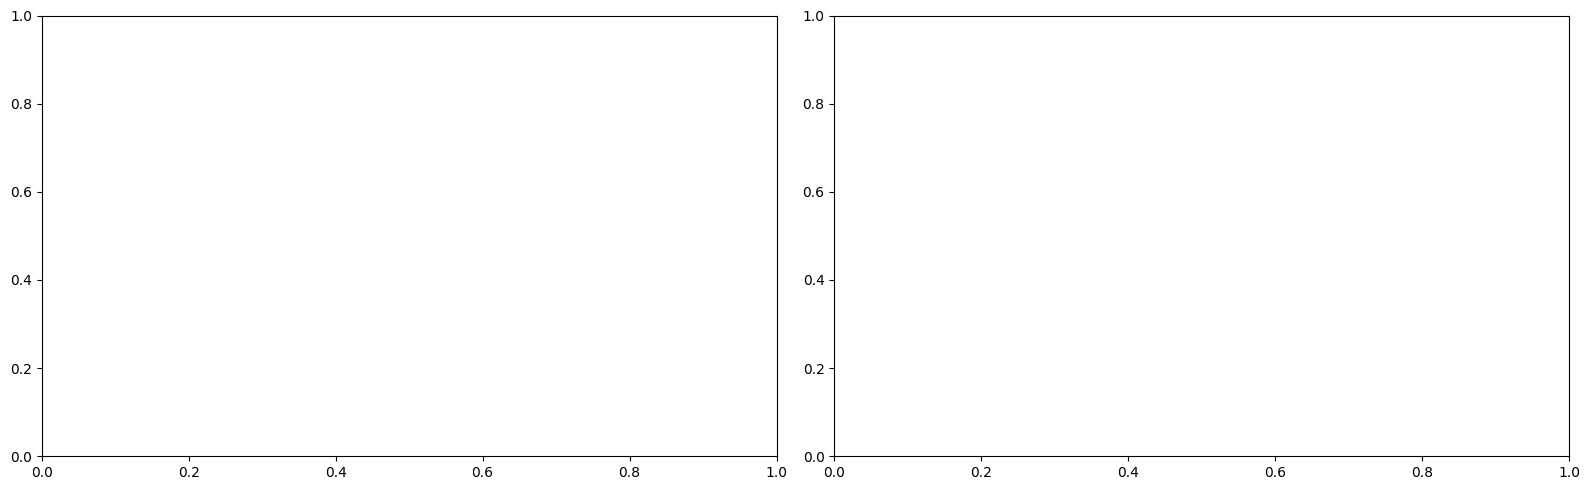


Total trials run : 15
Best trial number: 14
Best CV AUC      : 0.8677


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

try:
    optuna.visualization.matplotlib.plot_optimization_history(study, ax=axes[0])
    axes[0].set_title('Optuna Optimization History', fontweight='bold')

    optuna.visualization.matplotlib.plot_param_importances(study, ax=axes[1])
    axes[1].set_title('Hyperparameter Importance', fontweight='bold')
except Exception as e:
    print(f"Optuna plot note: {e}")

plt.tight_layout(); plt.show()

print(f"\nTotal trials run : {len(study.trials)}")
print(f"Best trial number: {study.best_trial.number}")
print(f"Best CV AUC      : {study.best_value:.4f}")


## 14. Results Summary (for Research Report)

In [18]:
summary = pd.DataFrame([{
    'Model':          'LightGBM (Corrected)',
    'Tuning':         f'Optuna ({OPTUNA_TRIALS} trials)',
    'SMOTE':          'Yes',
    'Threshold':      f'{best_thresh:.4f}',
    'Accuracy':       f'{accuracy_score(y_valid, val_preds_default):.4f}',
    'ROC AUC':        f'{roc_auc_score(y_valid, val_probs):.4f}',
    'F1 Macro':       f'{f1_score(y_valid, val_preds_default, average="macro"):.4f}',
    'F1 Weighted':    f'{f1_score(y_valid, val_preds_default, average="weighted"):.4f}',
    'Precision':      f'{precision_score(y_valid, val_preds_default, zero_division=0):.4f}',
    'Recall':         f'{recall_score(y_valid, val_preds_default, zero_division=0):.4f}',
    'Best Iteration': best_iter,
    'Data Leakage':   'None',
}])

print(summary.T.to_string(header=False))
summary.to_csv('model_results_summary.csv', index=False)
print("\nSaved: model_results_summary.csv")


Model           LightGBM (Corrected)
Tuning            Optuna (12 trials)
SMOTE                            Yes
Threshold                     0.3144
Accuracy                      0.7107
ROC AUC                       0.7465
F1 Macro                      0.6635
F1 Weighted                   0.7054
Precision                     0.5760
Recall                        0.5039
Best Iteration                   156
Data Leakage                    None

Saved: model_results_summary.csv


## 15. Save Model & Config

In [19]:
final_model.save_model('lgbm_flight_delay_corrected.txt')

joblib.dump({
    'threshold':        best_thresh,
    'best_iteration':   best_iter,
    'feature_cols':     list(X_train_res.columns),
    'categorical_cols': categorical_features,
    'label_encoders': le_dict,
    'optuna_best_params': study.best_params,
    'optuna_best_auc':  study.best_value,
}, 'model_config.pkl')

print("Saved:")
print("  lgbm_flight_delay_corrected.txt  — LightGBM booster")
print("  model_config.pkl                 — threshold, features, encoders")


Saved:
  lgbm_flight_delay_corrected.txt  — LightGBM booster
  model_config.pkl                 — threshold, features, encoders


## 16. Inference Helper

In [20]:
# def predict_delay(model, X_new, config):
#     """
#     Predict flight delay on new data.

#     Parameters
#     ----------
#     model  : loaded LightGBM booster (lgb.Booster)
#     X_new  : DataFrame with same columns as training features
#     config : dict loaded from model_config.pkl

#     Returns
#     -------
#     DataFrame with prediction, probability, and confidence
#     """
#     threshold     = config['threshold']
#     best_iter     = config['best_iteration']
#     le_dict       = config['label_encoders']
#     cat_cols      = config['categorical_cols']
#     feature_cols  = config['feature_cols']

#     X_new = X_new[feature_cols].copy()

#     for col in cat_cols:
#         if col in X_new.columns:
#             X_new[col] = le_dict[col].transform(X_new[col].astype(str))
#             X_new[col] = X_new[col].astype('category')

#     proba = model.predict(X_new, num_iteration=best_iter)
#     preds = (proba >= threshold).astype(int)

#     return pd.DataFrame({
#         'prediction':   preds,
#         'label':        ['Delayed' if p == 1 else 'On-Time' for p in preds],
#         'delay_prob':   proba.round(4),
#         'confidence':   np.where(preds==1, proba, 1-proba).round(4)
#     })

# # ── Example: predict on first 10 validation rows ─────────────────────────────
# config = joblib.load('model_config.pkl')
# loaded_model = lgb.Booster(model_file='lgbm_flight_delay_corrected.txt')
# sample_preds = predict_delay(loaded_model, X_valid_enc.head(10), config)
# print("Sample predictions:")
# print(sample_preds.to_string(index=False))
